# MURA XOR 공격 — 분류 결과 시각화

파인튜닝된 세 모델(Dict-16 / Dict-32 / Dict-64)을 MURA **valid split** 캡처에 대해 평가하고
- Confusion matrix 3패널
- Top-k accuracy

를 각각 PNG + PDF로 저장한다. 평가셋은 체크포인트가 학습에 쓰지 않은 valid split이며, aspect 스칼라는 관측 불가이므로 1.0으로 고정한다.

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
import common as c
from finetune_attack_model import build_model, load_dataset, _Subset

CLASSES = c.CLASSES
PANELS = [16, 32, 64]                          # dictionary sizes -> (a) Dict-16 ...
FT = {n: HERE / f"mura_attack_{n}ref_ft.pth" for n in PANELS}
OUT = HERE / "figures"
OUT.mkdir(exist_ok=True)


def evaluate(n_ref):
    """Confusion matrix (counts) and top-1/2/3 accuracy on the valid-split captures."""
    vx, vy, _ = load_dataset("valid", n_ref)
    model = build_model(n_ref, len(CLASSES))
    model.load_state_dict(torch.load(FT[n_ref], map_location="cpu", weights_only=True))
    model.eval()

    ld = DataLoader(_Subset(vx, vy, list(range(len(vy))), augment=False), batch_size=32)
    logits_all, trues = [], []
    with torch.no_grad():
        for xb, yb in ld:
            sc = torch.ones(len(xb), 1)        # aspect ratio is unobservable
            logits_all.append(model(xb, sc).numpy())
            trues += yb.tolist()
    logits = np.concatenate(logits_all)
    trues = np.array(trues)
    preds = logits.argmax(1)

    K = len(CLASSES)
    cm = np.zeros((K, K), dtype=int)
    for t, p in zip(trues, preds):
        cm[t, p] += 1
    rank = np.argsort(-logits, axis=1)
    topk = {k: float((rank[:, :k] == trues[:, None]).any(1).mean()) for k in (1, 2, 3)}
    return cm, topk


results = {n: evaluate(n) for n in PANELS}
for n in PANELS:
    cm, tk = results[n]
    print(f"Dict-{n}: n={cm.sum()}  top1={tk[1]*100:.1f}%  top2={tk[2]*100:.1f}%  top3={tk[3]*100:.1f}%")


/home/eun/open-science/case_study/mura/pipeline/finetune_attack_model.py:167: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return torch.from_numpy(np.ascontiguousarray(m)).float(), int(self.y[i])


Dict-16: n=765  top1=57.3%  top2=72.0%  top3=82.6%
Dict-32: n=765  top1=63.3%  top2=79.9%  top3=88.2%
Dict-64: n=765  top1=76.5%  top2=86.4%  top3=91.2%


saved: /home/eun/open-science/case_study/mura/pipeline/figures/mura_attack_cm_3panel.png | .pdf


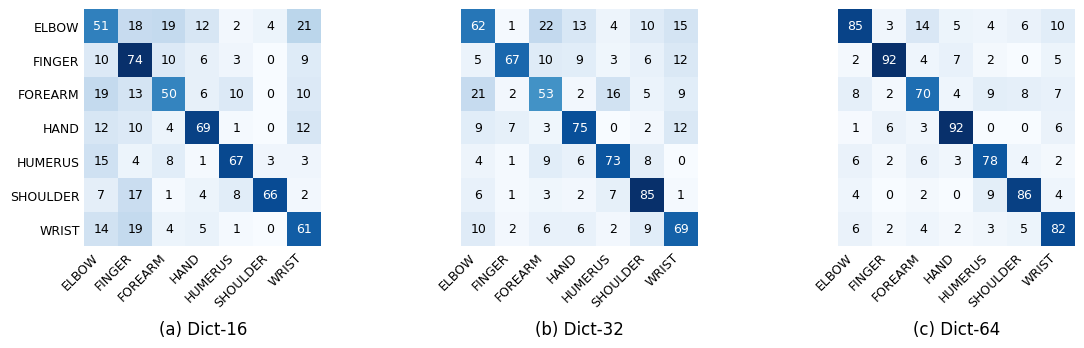

In [2]:
# ── Confusion matrix 3패널 (스타일: mura_xor_cm_3panel.png) ──────────────────
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

plt.rcParams.update({"font.size": 11, "font.family": "DejaVu Sans"})

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
cmap = plt.cm.Blues

for ax, n in zip(axes, PANELS):
    cm, _ = results[n]
    # Shade each row by its own scale so one dominant class does not flatten the rest,
    # matching the reference panels where off-diagonal counts stay readable.
    norm = Normalize(vmin=0, vmax=cm.max())
    ax.imshow(cm, cmap=cmap, norm=norm, aspect="equal")

    thresh = cm.max() * 0.6
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    fontsize=9,
                    color="white" if cm[i, j] > thresh else "black")

    ax.set_xticks(range(len(CLASSES)))
    ax.set_yticks(range(len(CLASSES)))
    ax.set_xticklabels(CLASSES, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(CLASSES if n == PANELS[0] else [""] * len(CLASSES), fontsize=9)
    ax.set_xlabel(f"({chr(97 + PANELS.index(n))}) Dict-{n}", fontsize=12, labelpad=8)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)

fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(OUT / f"mura_attack_cm_3panel.{ext}", bbox_inches="tight", dpi=200)
print("saved:", OUT / "mura_attack_cm_3panel.png", "| .pdf")
plt.show()


saved: /home/eun/open-science/case_study/mura/pipeline/figures/mura_attack_topk.png | .pdf


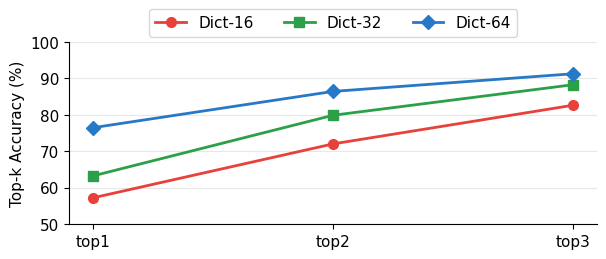

In [3]:
# ── Top-k accuracy (스타일: topk_accuracy.png) ───────────────────────────────
fig, ax = plt.subplots(figsize=(6.2, 2.8))

styles = {                                      # colour / marker per reference figure
    16: dict(color="#e8403a", marker="o", label="Dict-16"),
    32: dict(color="#2ca048", marker="s", label="Dict-32"),
    64: dict(color="#2878c8", marker="D", label="Dict-64"),
}
xs = [1, 2, 3]
for n in PANELS:
    _, tk = results[n]
    ys = [tk[k] * 100 for k in xs]
    ax.plot(xs, ys, linewidth=2, markersize=7, **styles[n])

ax.set_xticks(xs)
ax.set_xticklabels(["top1", "top2", "top3"])
ax.set_ylabel("Top-k Accuracy (%)")
ax.set_ylim(50, 100)
ax.grid(axis="y", linestyle="-", alpha=0.3)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.22), ncol=3, frameon=True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(OUT / f"mura_attack_topk.{ext}", bbox_inches="tight", dpi=200)
print("saved:", OUT / "mura_attack_topk.png", "| .pdf")
plt.show()
